## Program to create an averaged( 1°X1° Lat Lon) Themis Thermal Inertia Map

[Source - cub files from the website]('https://astrogeology.usgs.gov/maps/mars-themis-derived-global-thermal-inertia-mosaic?p=3&pb=1#downloads')

https://www.mars.asu.edu/data/thm_nir_100m/ 

The Themis IR Maps have the highest resolution amongst all other IR maps
- 593 ppd/100m (ppd = pixels per degree)

This also means that a large amount of data is stored in such files. Which is why they are stored as tiles 

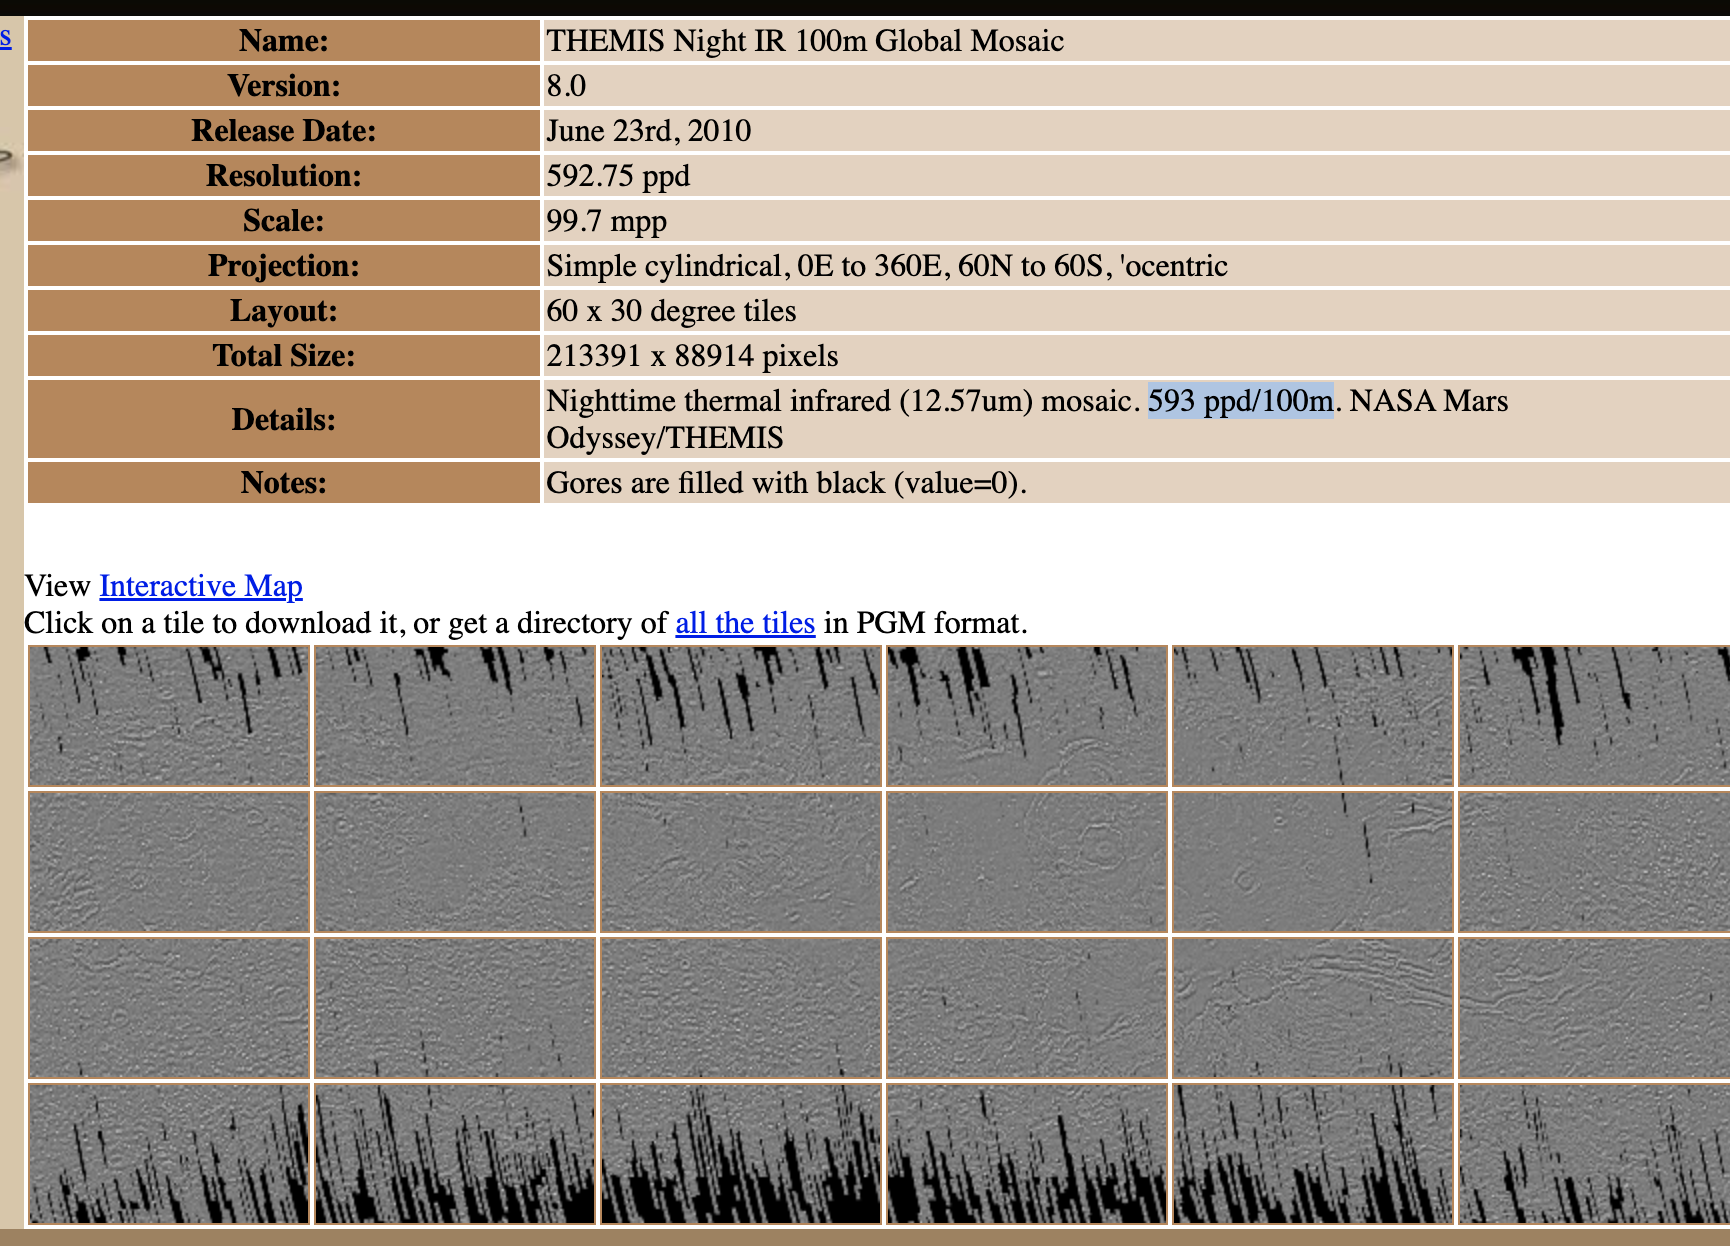

Each tile corressponds to the data available for that region given in this diagram

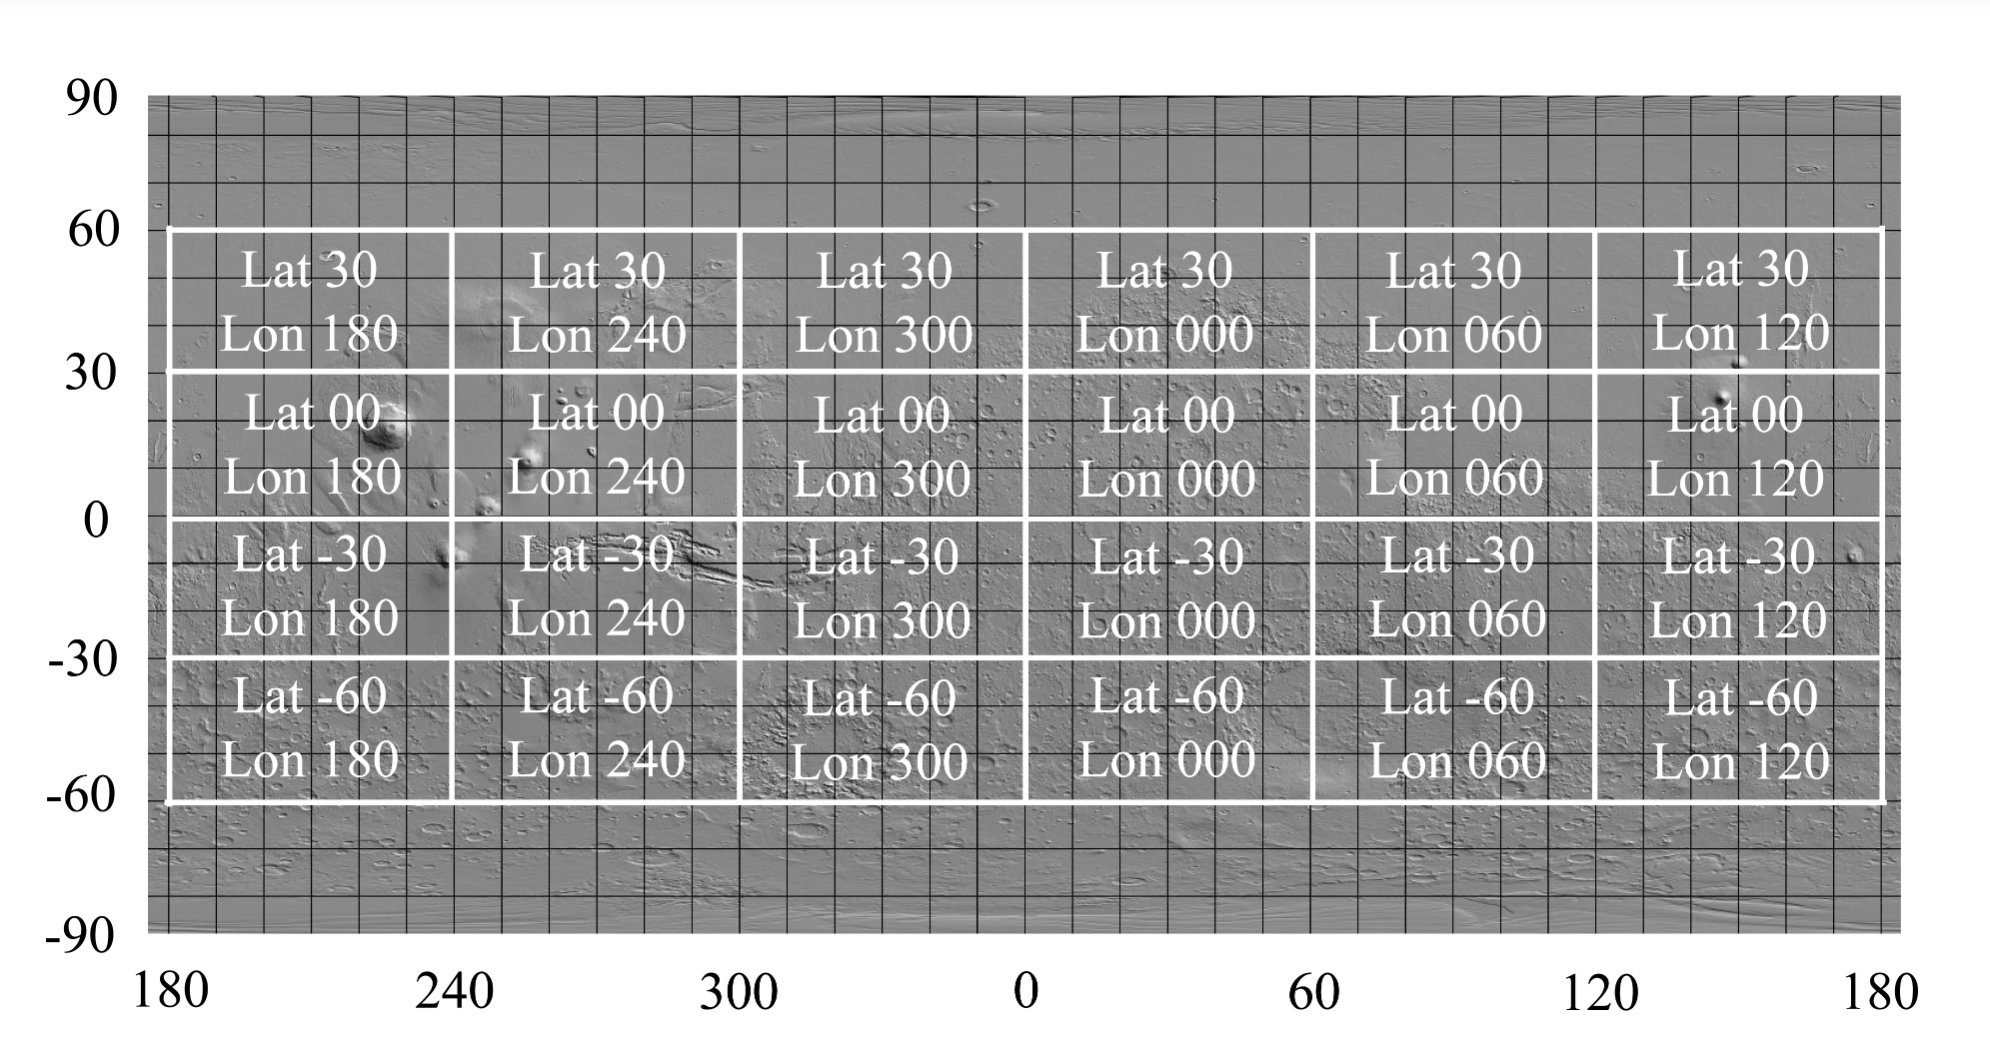

We process these tiles, and store them as numpy files to save space using the program
- themis_convert_image_data_numpy_average

The numpy files are averaged and stacked in the below program to create an averaged numpy array of the desired area. 

This array is then used to compare the values we get from krc in the EMM Thermal Inertia project

**Author**: Pallavi Krishna  
**Department**: MARS Research Lab NYUAD  
**Date**: April 2024  


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os

### Section1: Final Themis Files Processing Section

In [2]:
# Read themis file
themis_path = '/scratch/da99/marsatm/code_data/themis_thermal_inertia_data/themis_numpy_files'
themis_files = [x for x in os.listdir(themis_path) if '.npy' in x]
themis_files

['themis_ti_30lat_-120lon.npy',
 'themis_ti_30lat_120lon.npy',
 'themis_ti_-30lat_-120lon.npy',
 'themis_ti_0lat_-180lon.npy',
 'themis_ti_-30lat_-60lon.npy',
 'themis_ti_0lat_120lon.npy',
 'themis_ti_-60lat_60lon.npy',
 'themis_ti_30lat_0lon.npy',
 'themis_ti_30lat_-180lon.npy',
 'themis_ti_30lat_-60lon.npy',
 'themis_ti_-30lat_120lon.npy',
 'themis_ti_0lat_0lon.npy',
 'themis_ti_30lat_60lon.npy',
 'themis_ti_0lat_60lon.npy',
 'themis_ti_0lat_-120lon.npy',
 'themis_ti_-60lat_-60lon.npy',
 'themis_ti_-60lat_-120lon.npy',
 'themis_ti_-60lat_0lon.npy',
 'themis_ti_-30lat_0lon.npy',
 'themis_ti_-30lat_-180lon.npy',
 'themis_ti_-60lat_120lon.npy',
 'themis_ti_-30lat_60lon.npy',
 'themis_ti_-60lat_-180lon.npy',
 'themis_ti_0lat_-60lon.npy']

In [3]:
len(themis_files)

24

### Themis grid is 
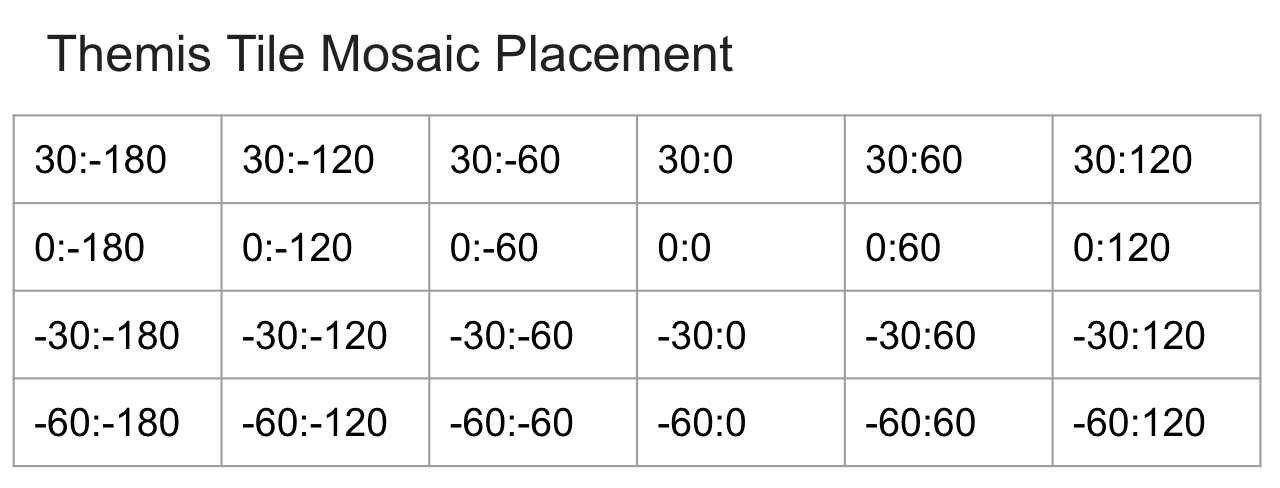
We want to stack this as a grid

| | | | | | |
|-|-|-|-|-|-|
|1|2|3|4|5|6|
|7|8|9|10|11|12|
|13|14|15|16|17|18|
|19|20|21|22|23|24|

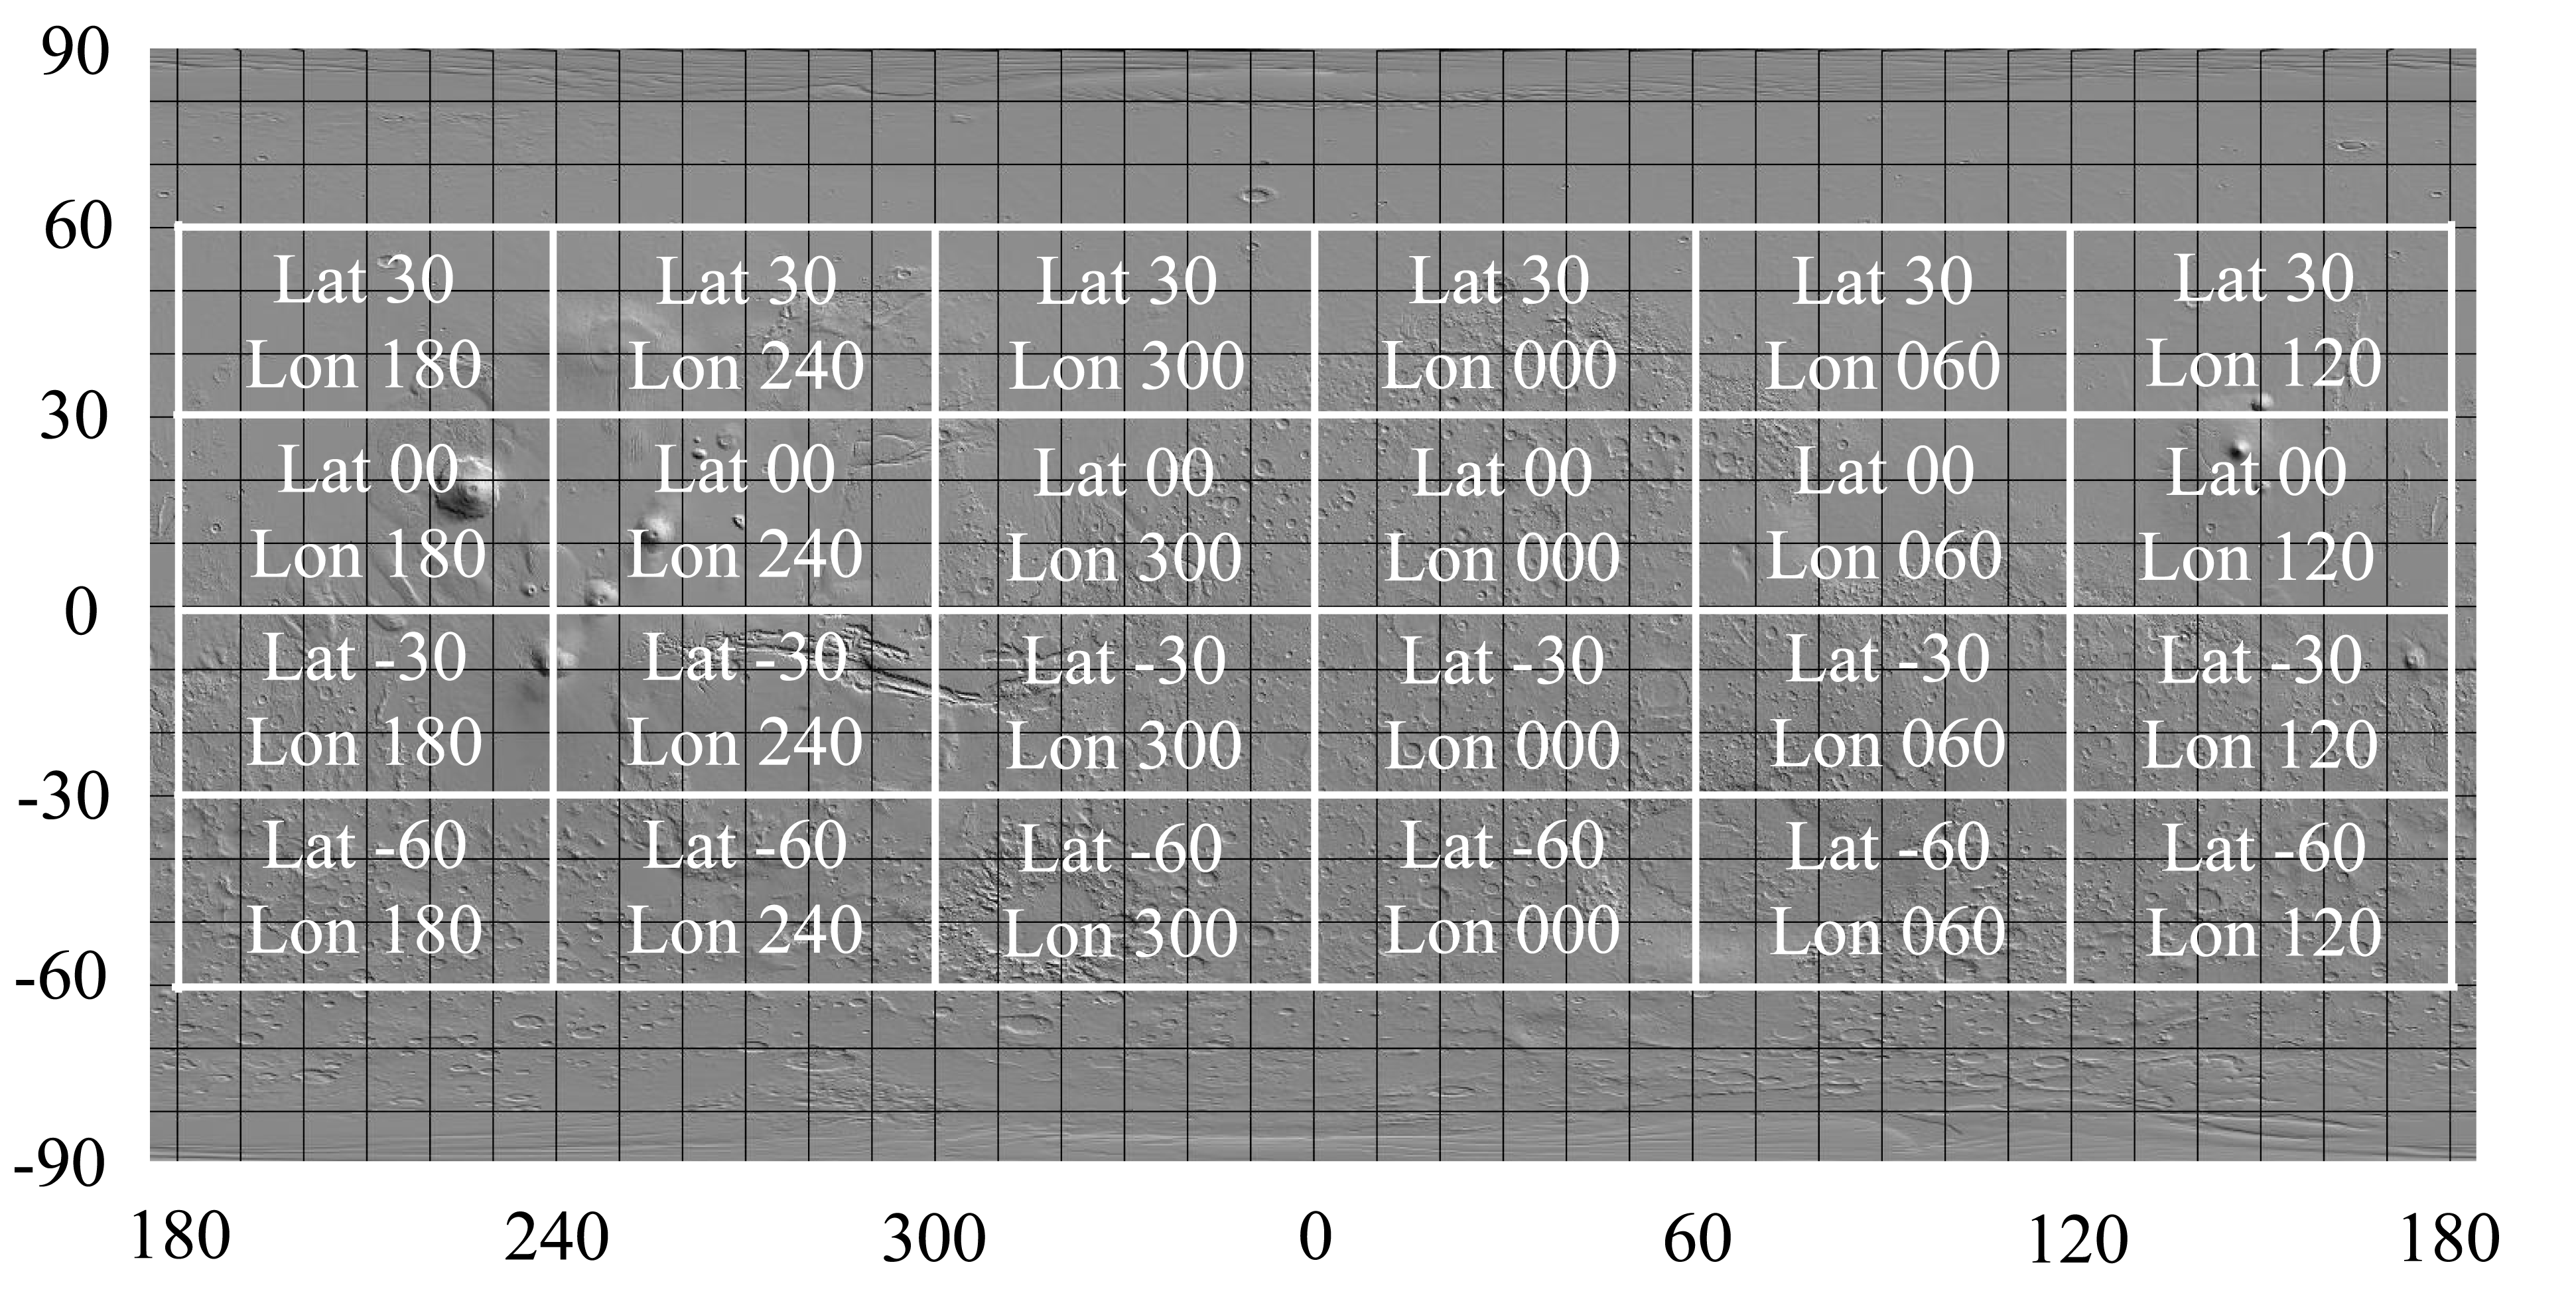


## Grid 1
Lat: 0 to 30  
Lon: 0 to 60

In [4]:
# Let's get the file for 2 grids Lat: 0 to 30, Lon: 0 to 60 
# Select Themis file from the tiles

f1 = 'themis_ti_0lat_0lon.npy'
arr1 = np.load(themis_path + '/'+f1)
arr1.shape

(17783, 35565)

In [6]:
def average_grid(arr, lat_giv, lon_giv):
    '''Function to average the grid size into 180 rows X 360 columns
    The Themis files size - 17783 rows X 35565 columns
    Each degree = 592.76 grid of pixels 
    As we cannot consider a decimal as index, we use 593 as our grid value
    I/P
    arr - the themis numpy array to be averaged
    grid_size_row - in this case 593
    grid_size_column - in this case 593
    lat_giv = 0 > 0 to 30
    lon_giv = 0 > 0 to 60'''
    
    # grid 
    lat_giv_st, lat_giv_end  = lat_giv, lat_giv + 30
    lon_giv_st, lon_giv_end  = lon_giv, lon_giv + 60   
 
    row_cnt = 0
    col_cnt = 0
    
    (lat_end, lon_end) = arr.shape
    deg_res = 593
    average_array = np.empty((180,360)) # 180 rows and 360 columns
    average_array[:] = np.nan
    
    for row in range(0, lat_end, deg_res): # lat loop
        col_cnt = 0 # reset cols
        for col in range(0, lon_end, deg_res): #lon loop
            
            new_lat = np.abs(row_cnt - 90)-1
            new_lon = col_cnt + 180
            #print(new_lat, new_lon)
            average_array[new_lat,new_lon] = arr[row:row+593, col:col+593].mean()
            
            col_cnt+=1
        row_cnt+=1
    return average_array
    

Using a function reduces the amount of data to be stored. For example if I was to average all the tiles and create a npy file, I could do this by not storing a single file from Themis. And only storing the numpy array. This increases efficiency and decreases time complexity

In [ ]:
average_array = average_grid(arr1, 0, 0)

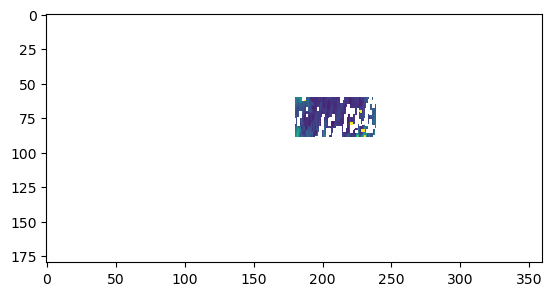

In [8]:
plt.imshow(average_array, vmin=0, vmax=800)

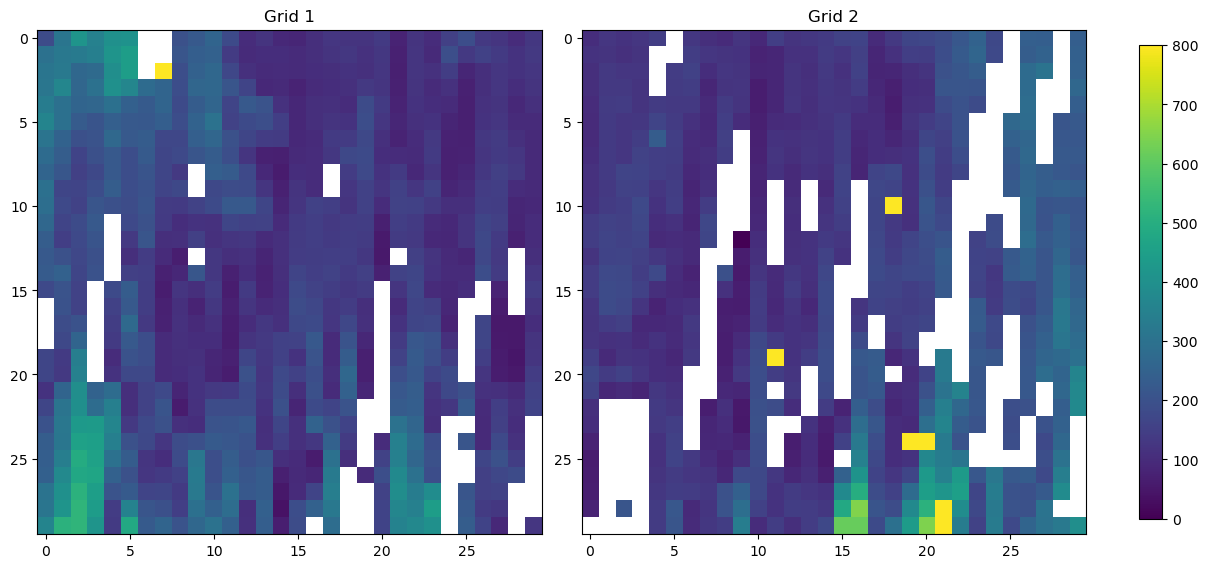

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)  

im1 = axes[0].imshow(average_array[60:90, 180:210], vmin=0, vmax=800)
axes[0].set_title('Grid 1')  # Add a title to the subplot

im2 = axes[1].imshow(average_array[60:90, 210:240], vmin=0, vmax=800)
axes[1].set_title('Grid 2')  # Add a title to the subplot

# Add a colorbar to the entire figure (optional, but often helpful)
fig.colorbar(im1, ax=axes, shrink=0.8)  

# Show the plot
plt.show()

In [31]:
# Save grid 1 
p_save = '/scratch/pk97/krc/krc_codes/Data/Themis_npy/'
f_save = 'Themis_npy_N30_S0_E60_W0.npy'
np.save(p_save+f_save, average_array)


# Grid 2
lat  0:30  
lon -60:0

In [14]:
# Let's get the file for 2 grids 
# Grid 1 file 
f1 = 'themis_ti_0lat_-60lon.npy' #grid3 and grid2
#f1 = 'themis_ti_0lat_0lon.npy' # grid1 and grid 4
arr1 = np.load(themis_path + '/'+f1)
arr1.shape

(17783, 35565)

We reuse same file area

In [19]:
def average_grid2(arr, lat_giv, lon_giv):
    '''Function to average the grid size into 180 rows X 360 columns
    The Themis files size - 17783 rows X 35565 columns
    Each degree = 592.76 grid of pixels 
    As we cannot consider a decimal as index, we use 593 as our grid value
    I/P
    arr - the themis numpy array to be averaged
    grid_size_row - in this case 593
    grid_size_column - in this case 593
    lat_giv = 0 > 0 to 30
    lon_giv = 0 > 0 to -60'''
    
    # grid 
    lat_giv_st, lat_giv_end  = lat_giv, lat_giv + 30
    lon_giv_st, lon_giv_end  = lon_giv, lon_giv + 60   
 
    row_cnt = 0 + lat_giv
    col_cnt = 0 + lon_giv
    
    (lat_end, lon_end) = arr.shape
    deg_res = 593
    average_array = np.empty((180,360)) # 180 rows and 360 columns
    average_array[:] = np.nan
    
    for row in range(0, lat_end, deg_res): # lat loop
        col_cnt = 0+lon_giv # reset cols
        for col in range(0, lon_end, deg_res): #lon loop
            
            new_lat = np.abs(row_cnt - 90)-1
            new_lon = col_cnt + 180
            #print(new_lat, new_lon)
            average_array[new_lat,new_lon] = arr[row:row+593, col:col+593].mean()
            
            col_cnt+=1
        row_cnt+=1
    return average_array
    

In [20]:
average_array = average_grid2(arr1, 0, -60)

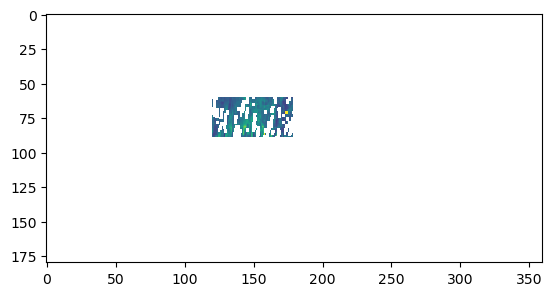

In [21]:
plt.imshow(average_array, vmin=0, vmax=800)

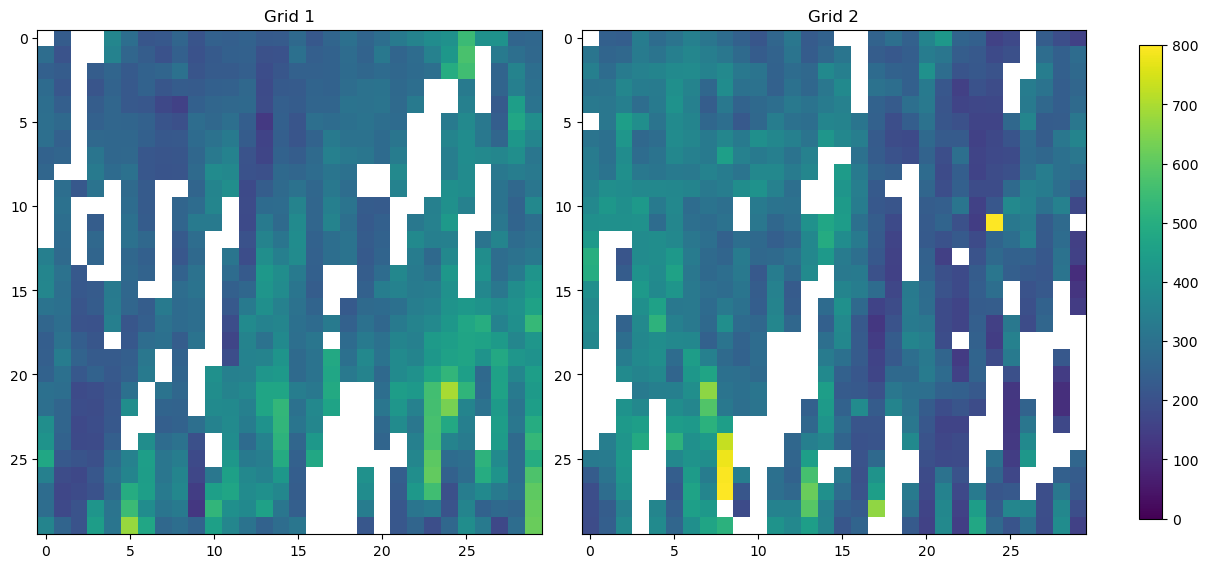

In [23]:

fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)  

im1 = axes[0].imshow(average_array[60:90, 120:150], vmin=0, vmax=800)
axes[0].set_title('Grid 1')  # Add a title to the subplot

im2 = axes[1].imshow(average_array[60:90, 150:180], vmin=0, vmax=800)
axes[1].set_title('Grid 2')  # Add a title to the subplot

# Add a colorbar to the entire figure (optional, but often helpful)
fig.colorbar(im1, ax=axes, shrink=0.8)  

# Show the plot
plt.show()

In [18]:
# Save grid 2 for future use
p_save = '/scratch/pk97/krc/krc_codes/Data/Themis_npy/'
f_save = 'Themis_npy_N30_S0_W60_E0.npy'
np.save(p_save+f_save, average_array)